In [75]:
import sys
sys.path.append('..')
from utils.filters import *
from utils.baseline_tools import *
from utils.gloer_tools import *
import pickle
import numpy as np

### I am doing the following things here 

1. Reformat the best orders of each model and export a csv
2. Create a image for every forecast and export them as a csv

## Prepare the model orders of all fits

In [85]:
all_locs = ["Fuerwigge", 'Moehne', 'Verse', 'Lister','Bigge', 'Sorpe',] # "Henne"
all_dirs = ['ver', "ew", "asc0", "desc0", "asc1", "desc1"]
grid_path = "../saves_and_results/grid_results_short"
fore = "../saves_and_results/forecasts_short"
out_path = "../saves_and_results/results_short"

for y in all_locs:
    for x in all_dirs:
        #load the orders and the model summaries
        try:
            path = grid_path + "/" + "grid_results_short_" + y + "_" + x + ".p"
            path2 = fore + "/" + y + "_" + x + "_summary" +  ".p"
            grid = pickle.load(open(path, "rb"))
            summary = pickle.load(open(path2, "rb"))
        except: 
            print("no combo:" + y + x)
            continue
        points = list(grid[0][-1].keys())
        out = []
        # For every PCI point
        for p in points: 
                # Get the best model.
                best = np.argsort([x[-1][p][0] for x in grid])[0]
                best = grid[best][:-1]

                # extract the values and the param names from the summary
                d = summary[p][0].tables[1].data
                names = [x[0] for x in d][1:]
                values = [x[1] for x in d][1:]
                values = [float(x.replace(" ", "")) for x in values]
                replace = [x for x in names if "x" in x]
                new = list(summary[p][1])
                assert len(replace ) == len(new)
                # Replace summary names with original exog names
                names = ["intercept"] + new + [x for x in names if "x" not in x][1:]
                out.append(pd.DataFrame(data = [values], columns = names, index = [p]))
        # Concat everything in one table and save ordered
        out = pd.concat(out)
        out = out[sorted(out.columns.values)]
        out.to_csv(out_path + "/" + y + "_" + x + "_" + "models.csv")

no combo:Fuerwiggeasc1
no combo:Fuerwiggedesc1
no combo:Versedesc1
no combo:Listerasc1
no combo:Listerdesc1
no combo:Biggeasc1
no combo:Biggedesc1
no combo:Sorpeasc1


## Display the forecasts and save them properly into a table

In [77]:
all_locs = ["Fuerwigge", 'Moehne', 'Verse', 'Lister','Bigge', 'Sorpe',] # "Henne"
all_dirs = ['ver', "ew", "asc0", "desc0", "asc1", "desc1"]
#fore = "forecasts"
#out_path = "results"
#img_path = "img"
fore = "../saves_and_results/forecasts_short"
out_path =  "../saves_and_results/results_short"
img_path =  "../saves_and_results/img_short"

fore2 = "../saves_and_results/var_forecasts_short"
out_path2 =  "../saves_and_results/var_results_short"
img_path2 =  "../saves_and_results/var_img_short"

data, meta = load_all_locations(path=data_source_path / "Datenpaket_BBD")
exogs = load_all_external(all_locs)

In [78]:
loc = "Lister"
direction = "asc0"
row_length = 2

In [79]:
path = fore +"/" + loc + "_" + direction + ".p"
path2 = fore + "/" + loc + "_" + direction + "_inSample.p"
res = pickle.load(open(path, "rb"))
inSample = pickle.load(open(path2, "rb"))

In [80]:
d = data[loc][direction]

In [81]:
y_ = d.loc[d.index.year == 2020]
original = pd.DataFrame(res)
original.index = y_.index
sa_n = pd.read_csv("forecasts/forecasts_"+ loc + "_" + direction + "_sarimax.csv", index_col = 0)[:61]
v_n = pd.read_csv("forecasts/forecasts_" + loc + "_" + direction + "_var.csv", index_col = 0)[:61]
f_n = pd.read_csv("forecasts/forecasts_" + loc + "_" + direction + "_forest.csv", index_col = 0)[:61]
y_ = d.loc[d.index.year == 2020]

In [82]:
a_ = pd.DataFrame(((original - y_) **2).mean())
b_ = ((y_ - sa_n.values) **2).mean()
c_ = ((y_ - v_n.values) **2).mean()
d_ = ((y_ - f_n.values) **2).mean()

In [83]:
out = pd.concat([a_,b_,c_,d_],axis=1)
out.columns = ["Original Sarimax", "New Sarimax", "VAR (multivariate)", "Random forest"]
out

,Original Sarimax,New Sarimax,VAR (multivariate),Random forest
720574,6.000587,5.962024,6.016479,6.495175
720593,10.944241,12.678561,6.979832,10.864219
720808,1.646591,1.835612,1.735078,1.730264
720906,12.327129,9.666613,9.930717,10.928623


In [34]:
# MAPE BROKEN AS FUCK
#mean_absolute_percentage_error(y_["260045"].values, sa_n["260045"].values)


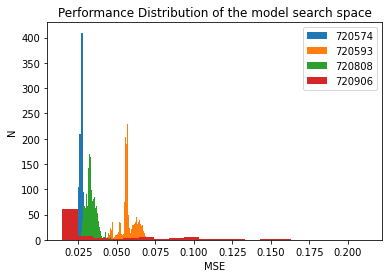

In [70]:
a = pickle.load(open("testing/Lister_asc0_sarimax_results_stack.p", "rb"))

plt.hist([x[1]['720574'][0] for x in a], bins = 50, density=True, label ='720574' )
plt.hist([x[1]['720593'][0] for x in a], bins = 50, density=True, label ='720593' )
plt.hist([x[1]['720808'][0] for x in a], bins = 50, density=True, label ='720808' )

plt.hist([x[1]['720906'][0] for x in a], bins = 20, density=True, label ='720906' )


plt.title("Performance Distribution of the model search space")
plt.xlabel("MSE")
plt.ylabel("N")
plt.legend()

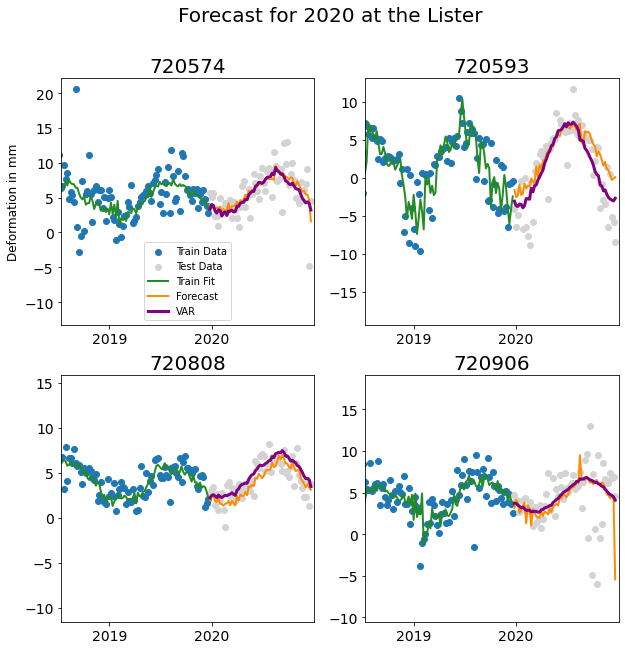

In [38]:

tickPos = np.where(d.index.weekofyear == 2)[0]
tickPos = [x for x in tickPos if x - 1 not in tickPos]
tickLabels = np.arange(2016, 2021)



rows = int(len(d.columns)/ row_length)
fig, axs = plt.subplots(rows, row_length, figsize=(5 * row_length, 5 * rows))
axs = axs.reshape(-1)
for n, key in enumerate(d.columns):
    train = d.loc[d.index.year < 2020, key].interpolate()
    test = d.loc[d.index.year >= 2020, key].interpolate()

    axs[n].scatter(np.arange(len(train)), train.values, label="Train Data")
    axs[n].scatter(np.arange(len(train), len(train)+ len(test)), test, label="Test Data", color="lightgrey")

    axs[n].set_title(key, fontsize=20)
    axs[n].tick_params(
        axis="both", which="major", labelsize=14
    )

    axs[n].set_xticks(
        ticks=tickPos, labels=tickLabels, fontsize=14
    )
    axs[n].plot(inSample[key], color="forestgreen", alpha=0.99, linewidth=2, label="Train Fit")
    axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], res[key], color="darkorange",alpha=1, linewidth=2, label="Forecast")
    #axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], sa_n[key], color="black", linewidth=3, label="Sarimax new")
    axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], v_n[key], color="purple", linewidth=3, label="VAR")
    #axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], f_n[key], color="darkblue", linewidth=3, label="Random forest")
    axs[n].set_xlim([200,351])

axs[0].legend()


axs[0].set_ylabel("Deformation in mm", fontsize=12)
fig.suptitle('Forecast for 2020 at the Lister', fontsize=20)


plt.savefig("../saves_and_results/original_predictions_mew.png", dpi=200)

In [12]:
def display_points(holder, row_length=8, header="", maxiTick=2021, plot_length=15):
    # takes in table and tries to display all ts
    cols = holder.columns
    subG = len(cols)
    rows = math.ceil(subG / row_length)
    print(subG)

    # calc which indices are the start of the year
    tickPos = np.where(pd.to_datetime(holder.index.values).weekofyear == 26)[0]
    tickPos = [x for x in tickPos if x - 1 not in tickPos]
    tickLabels = np.arange(2015, maxiTick)

    if subG > row_length:
        fig, axs = plt.subplots(
            rows, row_length, figsize=(plot_length * row_length, 5 * rows)
        )
        count = 0
        for n, key in enumerate(cols):
            if (n % row_length == 0) and (n != 0):
                count += 1
            axs[count, n % row_length].plot(holder[key].interpolate().values)
            axs[count, n % row_length].scatter(
                np.arange(len(holder)), holder[key].values
            )
            axs[count, n % row_length].set_title(key, fontsize=25)
            axs[count, n % row_length].tick_params(
                axis="both", which="major", labelsize=20
            )

            axs[count, n % row_length].set_xticks(
                ticks=tickPos, labels=tickLabels, fontsize=20
            )
    else:
        fig, axs = plt.subplots(1, subG, figsize=(30, 5 * rows))
        if subG == 1:
            axs = np.array([axs])

        for n, key in enumerate(cols):
            axs[n].plot(holder[key].interpolate().values)
            axs[n].scatter(np.arange(len(holder)), holder[key].values)
            axs[n].set_title(key)
    for n in range(rows):
        if rows < 2:
            axs[n].set_ylabel("Distance from start in mm", fontsize=20)
        else:
            axs[n, 0].set_ylabel("Distance from start in mm", fontsize=20)
    for n in range(row_length):
        if rows < 2:
            axs[min(n, subG - 1)].set_xlabel("Year", fontsize=20)
        else:
            axs[rows - 1, n].set_xlabel("Year", fontsize=20)
    fig.suptitle("PCI points (" + header + ")", fontsize=25)
    return fig, axs


In [13]:
count = 0
for loc in all_locs:
    for direction in all_dirs:
        try:
            path = fore +"/" + loc + "_" + direction + ".p"
            path2 = fore + "/" + loc + "_" + direction + "_inSample.p"
            res = pickle.load(open(path, "rb"))
            inSample = pickle.load(open(path2, "rb"))
        except: 
            print("no combo:" + loc + direction)
            continue





        fig, axs = display_points(out[0],maxiTick=mT, row_length=3, header = "direction")
        remove_lines(axs)
        for y in axs.reshape(-1):
            n = y.title.get_text()
            if n == "":
                pass
            else:
                y.plot(np.arange(len(out[0]), len(out[0]) + len(df)),df[n].values)
                y.plot(inSample[n])
        fig.savefig(img_path + "/" + loc + "_" + direction + ".png", dpi=fig.dpi)
        df.to_csv(out_path + "/" + loc + "_" + direction + ".csv")

KeyError: 0